In [ ]:
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt

# Modell und Matchup-Daten laden
model_path = os.path.join('..', 'models', 'xgboost_wm_modelV2.joblib')
matchup_path = os.path.join('..', 'data', 'processed', 'model_input', 'matchup_features.csv')

model = joblib.load(model_path)
matchup_df = pd.read_csv(matchup_path)

print("🔮 Das WM-Orakel ist bereit!")

🔮 Das WM-Orakel ist bereit!


In [5]:
def predict_match_visual(team_a, team_b):
    # Matchup suchen
    match = matchup_df[(matchup_df['Team_A'] == team_a) & (matchup_df['Team_B'] == team_b)]
    reversed_match = False
    
    if match.empty:
        match = matchup_df[(matchup_df['Team_A'] == team_b) & (matchup_df['Team_B'] == team_a)]
        reversed_match = True
        
    if match.empty:
        return f"Keine Daten für {team_a} oder {team_b} vorhanden."
        
    # Features extrahieren
    features = [
        'Delta_Total_Market_Value', 'Delta_Median_Top11_Value', 'Delta_Chemistry',
        'Delta_Form_Rating', 'Delta_UCL_Minutes', 'Delta_Tournament_Minutes',
        'Delta_Average_Age', 'Delta_TM_Value_Rank', 'Delta_FIFA_Rank', 'Delta_FIFA_Points'
    ]
    
    X_pred = match[features].copy()
    if reversed_match:
        X_pred = X_pred * -1
        
    # Wahrscheinlichkeiten berechnen
    probs = model.predict_proba(X_pred)[0]
    
    # Ergebnisse visualisieren
    outcomes = [f"Sieg {team_b}", "Unentschieden", f"Sieg {team_a}"]
    colors = ['#ff9999','#66b3ff','#99ff99']
    
    plt.figure(figsize=(8, 4))
    plt.barh(outcomes, probs, color=colors)
    plt.xlim(0, 1)
    plt.title(f"Prognose: {team_a} vs. {team_b}")
    plt.xlabel("Wahrscheinlichkeit")
    
    for i, v in enumerate(probs):
        plt.text(v + 0.01, i, f"{v*100:.1f}%", fontweight='bold')
        
    plt.show()

    # Textuelle Zusammenfassung
    winner_idx = probs.argmax()
    if winner_idx == 2: print(f"🏆 Tendenz: {team_a} gewinnt!")
    elif winner_idx == 0: print(f"🏆 Tendenz: {team_b} gewinnt!")
    else: print("⚖️ Tendenz: Unentschieden / Verlängerung")

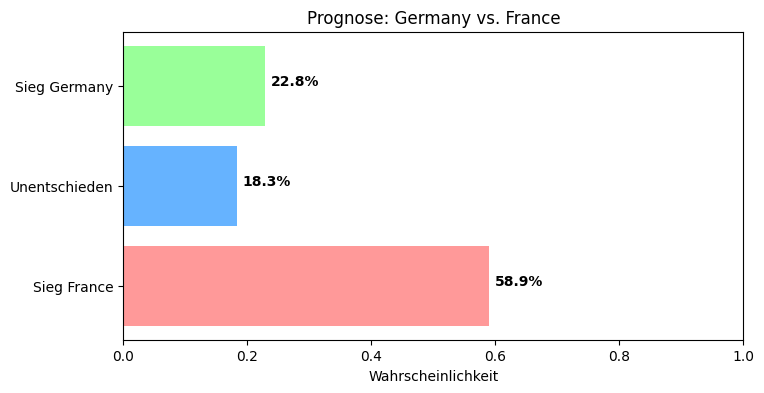

🏆 Tendenz: France gewinnt!


In [6]:
# Du kannst hier 'Argentina', 'Brazil', 'France', 'Germany' oder 'Switzerland' einsetzen
predict_match_visual('Germany', 'France')